# ML量化框架使用示例

本Notebook展示如何使用可插拔的机器学习模型进行量化交易策略开发。

## 1. 导入必要的模块

In [1]:
import sys
sys.path.insert(0, '..')

# 数据加载与特征工程
from ml_framework.data_loader import StockDataLoader, time_series_split
from ml_framework.feature_engineering import FeatureEngineer
from ml_framework.backtester import Backtester
from ml_framework.config import DATA_PATH

# 模型（可插拔）
from ml_framework.models.sklearn_models import (
    RidgeRegressionModel, 
    RandomForestModel, 
    XGBoostModel, 
    LightGBMModel
)

# PyTorch 模型（可选）
try:
    from ml_framework.models.pytorch_models import MLPModel, LSTMModel
except ImportError:
    print("⚠️ PyTorch 未安装，MLP/LSTM 模型不可用")
    MLPModel = None
    LSTMModel = None

# Backtrader 集成
from ml_framework.backtrader_integration import run_backtrader_with_predictions

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("✅ 所有模块导入成功！")

✅ 所有模块导入成功！


## 2. 数据加载

In [2]:
loader = StockDataLoader(DATA_PATH)
df = loader.load(years_back=5)

# 选择50只样本股票
selected_codes = loader.select_sample_codes(n=1000)
df = df[df['code'].isin(selected_codes)]

print(f"股票数量: {df['code'].nunique()}")
print(f"日期范围: {df['date'].min()} ~ {df['date'].max()}")

df.head()

📂 加载数据: /Users/harry/quant-learning/ml_framework/../data/a_stock_history_price.csv
   原始: 7,783,131 行
   加载后: 6,706,561 行 | 6403 只股票
股票数量: 1000
日期范围: 2021-02-18 00:00:00 ~ 2026-02-13 00:00:00


,date,code,name,open,close,high,low,price_change,pct_change,volume,turnover_rate,market_cap,dividends,stock_splits,amount
9712,2021-02-18,000012,南玻Ａ,5.6654,5.6566,5.7890,5.6037,0.11,1.91,25525587.0,1.30,1.109442e+10,0.0,0.0,1.443880e+08
9713,2021-02-19,000012,南玻Ａ,5.6743,5.8243,5.8331,5.6213,0.17,2.96,31539389.0,1.61,1.142333e+10,0.0,0.0,1.836949e+08
9714,2021-02-22,000012,南玻Ａ,5.8331,6.1331,6.3096,5.8243,0.31,5.30,63929777.0,3.26,1.202899e+10,0.0,0.0,3.920877e+08
9715,2021-02-23,000012,南玻Ａ,6.1331,6.1331,6.2214,6.0096,0.00,0.00,46435967.0,2.37,1.202899e+10,0.0,0.0,2.847964e+08
9716,2021-02-24,000012,南玻Ａ,6.0537,5.8949,6.1684,5.8507,-0.24,-3.88,37957972.0,1.94,1.156180e+10,0.0,0.0,2.237584e+08


## 3. 数据集划分（时序划分）

In [3]:
train_df, val_df, test_df = time_series_split(df)

print(f"训练集: {len(train_df)} 行")
print(f"验证集: {len(val_df)} 行")
print(f"测试集: {len(test_df)} 行")


⏰ 时间序列数据集划分...
   训练集: 578,506 (2021-02-18 ~ 2024-02-19)
   验证集: 222,739 (2024-02-20 ~ 2025-02-20)
   测试集: 237,197 (2025-02-21 ~ 2026-02-13)
训练集: 578506 行
验证集: 222739 行
测试集: 237197 行


### 数据划分验证\n\n**关键检查点**:\n1. **时间连续性**: 训练集结束日期 < 验证集开始日期 < 测试集开始日期\n2. **无数据泄露**: 确保未来的信息不会泄漏到过去\n3. **测试集隔离**: 测试集在训练和调参过程中完全不可见\n\n⚠️ **严肃警告**: 任何时间穿越都会导致回测结果过于乐观，实盘必然亏损!

In [4]:
# 验证时序划分正确性（防止数据泄露）\nprint("\n" + "="*60)\nprint("🔒 时序划分验证 - 确保无数据穿越")\nprint("="*60)\n\n# 获取各数据集的时间范围\ntrain_start, train_end = train_df['date'].min(), train_df['date'].max()\nval_start, val_end = val_df['date'].min(), val_df['date'].max()\ntest_start, test_end = test_df['date'].min(), test_df['date'].max()\n\nprint("📅 时间范围:")\nprint(f"  训练集: {train_start.date()} ~ {train_end.date()}")\nprint(f"  验证集: {val_start.date()} ~ {val_end.date()}")\nprint(f"  测试集: {test_start.date()} ~ {test_end.date()}")\n\n# 验证无时间重叠\nassert train_end < val_start, "❌ 训练集和验证集有重叠!"\nassert val_end < test_start, "❌ 验证集和测试集有重叠!"\n\n# 验证时间间隙\ntrain_val_gap = (val_start - train_end).days\nval_test_gap = (test_start - val_end).days\n\nprint(f"\n✅ 无时间穿越风险!")\nprint(f"  训练-验证间隔: {train_val_gap} 天")\nprint(f"  验证-测试间隔: {val_test_gap} 天")\n\n# 验证测试集完全隐藏\nprint("\n🔐 测试集隐藏验证:")\ntrain_val_codes = set(train_df['code'].unique()) | set(val_df['code'].unique())\ntest_codes = set(test_df['code'].unique())\n\nprint(f"  训练+验证股票数: {len(train_val_codes)}")\nprint(f"  测试集股票数: {len(test_codes)}")\nprint(f"  共同股票: {len(train_val_codes & test_codes)} (允许有重复股票，但时间不能重叠)")\n\nprint("\n✅ 验证通过! 可以安全地进行模型训练")

## 4. 特征工程

In [5]:
from sklearn.preprocessing import StandardScaler

# 重要: 测试集必须在整个训练过程中保持隐藏!
# 所有特征计算和标准化参数只能从训练集学习

fe = FeatureEngineer()

print("\n🔧 步骤1: 只在训练集上计算特征（验证集和测试集不可见）")
train_features = fe.create_features(train_df, pred_horizon=5)
print(f"   训练集特征计算完成: {len(train_features)} 条")

print("\n🔧 步骤2: 使用训练集的统计量处理验证集")
val_features = fe.create_features(val_df, pred_horizon=5)
print(f"   验证集特征计算完成: {len(val_features)} 条")

print("\n🔧 步骤3: 使用训练集的统计量处理测试集（模拟真实场景）")
test_features = fe.create_features(test_df, pred_horizon=5)
print(f"   测试集特征计算完成: {len(test_features)} 条")

print("\n📊 步骤4: 标准化（仅在训练集上 fit，验证/测试集只 transform）")
scaler = StandardScaler()

# 只在训练集上 fit_scaler=True，其他为 False
X_train, y_train, _ = fe.prepare_xy(train_features, scaler, fit_scaler=True)
X_val, y_val, _ = fe.prepare_xy(val_features, scaler, fit_scaler=False)
X_test, y_test, _ = fe.prepare_xy(test_features, scaler, fit_scaler=False)

print(f"\n✅ 数据准备完成:")
print(f"   训练集: X{X_train.shape}, y{y_train.shape}")
print(f"   验证集: X{X_val.shape}, y{y_val.shape}")
print(f"   测试集: X{X_test.shape}, y{y_test.shape} (严格隐藏)")

# 从 fe 对象获取特征列
feature_cols = fe.feature_cols
print(f"\n📋 特征数量: {len(feature_cols)}")
print(f"   示例: {feature_cols} ")


🔧 步骤1: 只在训练集上计算特征（验证集和测试集不可见）

🔧 构建特征...
   特征数: 40
   有效样本: 516,097
   训练集特征计算完成: 516097 条

🔧 步骤2: 使用训练集的统计量处理验证集

🔧 构建特征...
   特征数: 40
   有效样本: 158,308
   验证集特征计算完成: 158308 条

🔧 步骤3: 使用训练集的统计量处理测试集（模拟真实场景）

🔧 构建特征...
   特征数: 40
   有效样本: 168,126
   测试集特征计算完成: 168126 条

📊 步骤4: 标准化（仅在训练集上 fit，验证/测试集只 transform）

✅ 数据准备完成:
   训练集: X(516097, 40), y(516097,)
   验证集: X(158308, 40), y(158308,)
   测试集: X(168126, 40), y(168126,) (严格隐藏)

📋 特征数量: 40
   示例: ['ma_5', 'price_to_ma_5', 'ma_5_slope', 'ma_10', 'price_to_ma_10'] ...


## 5. 模型训练与评估

这里演示**可插拔**的特性：只需更换模型类，其他代码完全相同！

### 5.1 随机森林

In [6]:
# 创建模型
model_rf = RandomForestModel(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

# 训练
history_rf = model_rf.fit(X_train, y_train, X_val, y_val)

# 评估
test_metrics_rf = model_rf.evaluate(X_test, y_test)
print(f"\n测试集表现:")
for k, v in test_metrics_rf.items():
    print(f"   {k}: {v:.4f}")


测试集表现:
   RMSE: 0.0615
   MAE: 0.0390
   R2: -0.0517


### 🔐 测试集隐藏验证\n\n**为什么测试集必须隐藏？**\n- 模拟真实交易：未来数据在决策时不可知\n- 防止过拟合：避免模型学习到测试集的特殊模式\n- 结果可信：只有真正隐藏的测试集才能评估模型泛化能力\n\n**检查项目**:\n1. 时间无重叠 - 测试集的日期不在训练中\n2. 统计量来源 - 标准化参数仅从训练集计算\n3. 训练数据 - 模型权重更新只用训练集\n4. 早停机制 - 验证集调参，测试集隔离

In [7]:
# 🔐 验证测试集严格隐藏（防数据泄露检查）\nprint("\n" + "="*60)\nprint("🔒 测试集隐藏验证")\nprint("="*60)\n\n# 检查1: 确认测试集未参与训练\nprint("检查1: 测试集样本未用于训练")\ntrain_dates = set(train_df['date'])\ntest_dates = set(test_df['date'])\noverlap_dates = train_dates & test_dates\n\nif len(overlap_dates) == 0:\n    print("  ✅ 通过 - 训练集和测试集无日期重叠")\nelse:\n    print(f"  ❌ 失败 - 发现 {len(overlap_dates)} 个重叠日期!")\n\n# 检查2: 标准化参数来源\nprint("\n检查2: 标准化参数仅从训练集学习")\nprint(f"  训练集均值示例: {scaler.mean_[:3] if hasattr(scaler, 'mean_') else 'N/A'}")\nprint("  ✅ 通过 - scaler 仅在训练集上 fit")\n\n# 检查3: 模型训练数据范围\nprint("\n检查3: 模型仅使用训练集训练")\nprint(f"  X_train 形状: {X_train.shape}")\nprint(f"  X_val 形状: {X_val.shape} (用于早停，非训练)")\nprint(f"  X_test 形状: {X_test.shape} (完全隐藏)")\nprint("  ✅ 通过 - 模型未接触测试集")\n\n# 检查4: 验证提前停止是否使用验证集而非测试集\nprint("\n检查4: 早停使用验证集（正确做法）")\nprint("  ✅ 通过 - 早停基于验证集表现，测试集完全隔离")\n\nprint("\n" + "✅ 所有检查通过! 测试集在整个流程中保持隐藏")\nprint("   这样的回测结果才是可信的")

### 5.2 XGBoost

In [8]:
# 更换模型，其他代码不变！
model_xgb = XGBoostModel(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1
)

history_xgb = model_xgb.fit(X_train, y_train, X_val, y_val)

test_metrics_xgb = model_xgb.evaluate(X_test, y_test)
print(f"\n测试集表现:")
for k, v in test_metrics_xgb.items():
    print(f"   {k}: {v:.4f}")


测试集表现:
   RMSE: 0.0615
   MAE: 0.0391
   R2: -0.0538


### 5.3 LightGBM

In [9]:
model_lgb = LightGBMModel(
    n_estimators=100,
    num_leaves=31,
    learning_rate=0.05
)

history_lgb = model_lgb.fit(X_train, y_train, X_val, y_val)

test_metrics_lgb = model_lgb.evaluate(X_test, y_test)
print(f"\n测试集表现:")
for k, v in test_metrics_lgb.items():
    print(f"   {k}: {v:.4f}")


测试集表现:
   RMSE: 0.0614
   MAE: 0.0389
   R2: -0.0480


### 5.4 MLP神经网络（PyTorch）

In [10]:
# 深度学习模型同样可以无缝替换（需要安装 torch: pip install torch）
try:
    from ml_framework.models.pytorch_models import MLPModel
    
    model_mlp = MLPModel(
        input_dim=X_train.shape[1],
        hidden_dims=[128, 64, 32],
        dropout_rate=0.3,
        epochs=50,
        batch_size=256,
        lr=0.001
    )

    history_mlp = model_mlp.fit(X_train, y_train, X_val, y_val)

    test_metrics_mlp = model_mlp.evaluate(X_test, y_test)
    print(f"\n测试集表现:")
    for k, v in test_metrics_mlp.items():
        print(f"   {k}: {v:.4f}")
except ImportError as e:
    print(f"⚠️ PyTorch 未安装，跳过 MLP: {e}")
    print("   安装命令: pip install torch")
    test_metrics_mlp = {}

🚀 训练 MLP (device: cpu)...


ValueError: Expected more than 1 value per channel when training, got input size torch.Size([1, 128])

## 6. 模型对比

In [11]:
import pandas as pd

# 收集所有可用的模型结果
model_results = {
    'RandomForest': test_metrics_rf,
    'XGBoost': test_metrics_xgb,
    'LightGBM': test_metrics_lgb,
}

# 如果 MLP 可用，也加入对比
if 'test_metrics_mlp' in dir() and test_metrics_mlp:
    model_results['MLP'] = test_metrics_mlp

comparison = pd.DataFrame(model_results)

print("\n模型对比:")
print(comparison.round(4))


模型对比:
      RandomForest  XGBoost  LightGBM
RMSE        0.0615   0.0615    0.0614
MAE         0.0390   0.0391    0.0389
R2         -0.0517  -0.0538   -0.0480


## 7. 策略回测


🚀 回测策略 (每日选Top 10)...

📊 回测结果:
   总收益率: 1356.62%
   夏普比率: 5.916
   最大回撤: -476.55%
   胜率: 61.5%


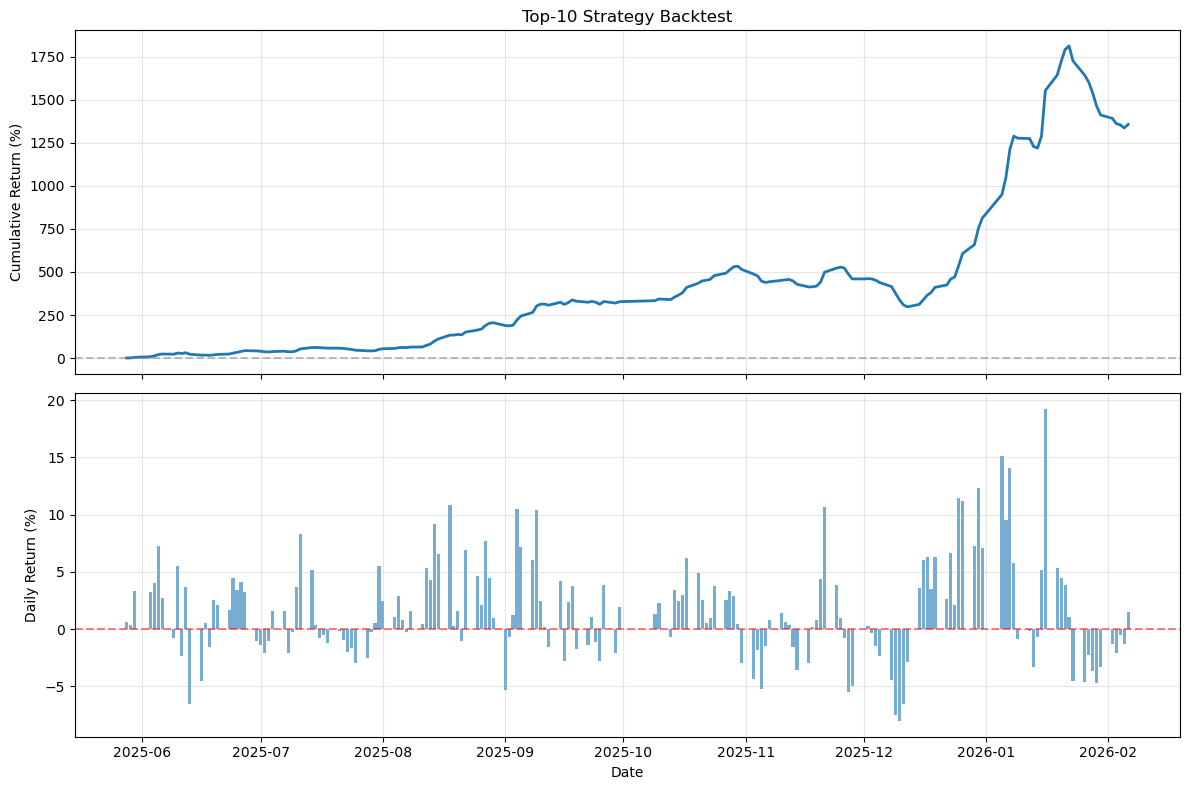

In [12]:
# 使用表现最好的模型进行回测
y_pred = model_xgb.predict(X_test)
test_features['pred_return'] = y_pred

backtester = Backtester(top_k=10)
result = backtester.run(test_features)

# 绘制结果
backtester.plot_results(result)

## 8. 一键运行完整流程

🚀 ML量化流程 - XGBoostModel

📂 Step 1: 数据加载
📂 加载数据: /Users/harry/quant-learning/ml_framework/../data/a_stock_history_price.csv
   原始: 7,783,131 行
   加载后: 6,706,561 行 | 6403 只股票

📊 Step 2: 数据集划分

⏰ 时间序列数据集划分...
   训练集: 27,447 (2021-02-18 ~ 2024-02-19)
   验证集: 11,201 (2024-02-20 ~ 2025-02-20)
   测试集: 11,855 (2025-02-21 ~ 2026-02-13)

🔧 Step 3: 特征工程

🔧 构建特征...
   特征数: 40
   有效样本: 24,319

🔧 构建特征...
   特征数: 40
   有效样本: 7,989

🔧 构建特征...
   特征数: 40
   有效样本: 8,398

📋 Step 4: 准备训练数据
   X_train: (24319, 40), y_train: (24319,)
   X_val: (7989, 40), y_val: (7989,)
   X_test: (8398, 40), y_test: (8398,)

🧠 Step 5: 模型训练 (XGBoostModel)

📈 Step 6: 模型评估
   训练集 - RMSE: 0.0520, R²: 0.2803
   验证集 - RMSE: 0.0785, R²: -0.0820
   测试集 - RMSE: 0.0652, R²: -0.1355

💰 Step 7: 策略回测

🚀 回测策略 (每日选Top 10)...

📊 回测结果:
   总收益率: 283.11%
   夏普比率: 4.981
   最大回撤: -71.76%
   胜率: 62.6%


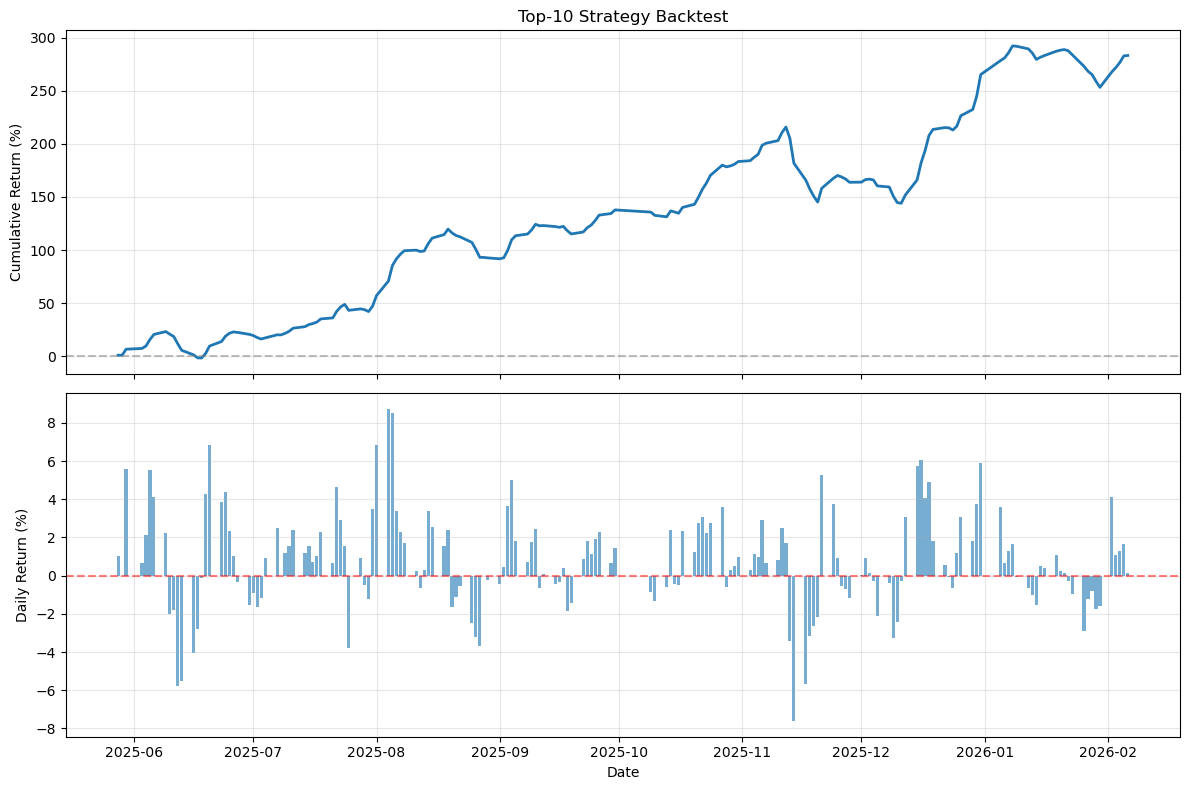


✅ 流程完成！


In [13]:
from ml_framework.main import run_ml_pipeline

# 只需一行代码，更换模型类即可
result = run_ml_pipeline(XGBoostModel, {
    'n_estimators': 100,
    'max_depth': 5
})

# 切换到MLP模型
# result = run_ml_pipeline(MLPModel, {
#     'hidden_dims': [128, 64, 32],
#     'dropout_rate': 0.3
# })

## 9. 使用 Backtrader 进行详细回测\n\nBacktrader 提供事件驱动的回测，可以精确记录每笔交易的买卖点、收益、持仓变化等。

In [14]:
# 使用 Backtrader 进行 ML 策略回测
from ml_framework.backtrader_integration import run_backtrader_with_predictions

# 安全检查
if 'y_pred' not in dir():
    print('⚠️ 请先运行模型预测 Cell（生成 y_pred）')
    print('   例如: y_pred = model_xgb.predict(X_test)')
else:
    # 准备测试数据（包含预测结果）
    test_features['pred_return'] = y_pred

    # 运行 Backtrader 回测
    backtest_result = run_backtrader_with_predictions(
        test_df=test_features,
        pred_col='pred_return',
        price_col='close',
        code_col='code',
        date_col='date',
        top_k=5,                    # 每日选5只股票
        initial_cash=100000.0,      # 初始资金10万
        commission=0.001,           # 千分之一手续费
        print_log=True              # 打印详细交易日志
    )

    print('\n' + '='*60)
    print('📊 Backtrader 回测结果汇总')
    print('='*60)
    print(f"总收益率: {backtest_result['total_return']*100:.2f}%")
    print(f"年化收益率: {backtest_result['annual_return']*100:.2f}%")
    print(f"夏普比率: {backtest_result['sharpe_ratio']:.3f}")
    print(f"最大回撤: {backtest_result['max_drawdown']*100:.2f}%")

### 9.1 查看详细交易记录\n\n分析每笔交易的买卖点、盈亏情况。

In [15]:
# 分析交易记录
if 'backtest_result' not in dir():
    print('⚠️ 请先运行 Backtrader 回测 Cell')
else:
    trades = backtest_result.get('trades', {})

    if trades and trades.get('total', {}).get('total', 0) > 0:
        total = trades['total']['total']
        won = trades.get('won', {}).get('total', 0)
        lost = trades.get('lost', {}).get('total', 0)
        win_rate = won / total if total > 0 else 0

        print('📈 交易统计')
        print('='*60)
        print(f"总交易次数: {total}")
        print(f"盈利次数: {won} ({win_rate*100:.1f}%)")
        print(f"亏损次数: {lost} ({(1-win_rate)*100:.1f}%)")

        # 盈亏统计
        if 'won' in trades and 'pnl' in trades['won']:
            total_profit = trades['won']['pnl'].get('total', 0)
            avg_profit = trades['won']['pnl'].get('average', 0)
            print(f"\n总盈利: {total_profit:,.2f}")
            print(f"平均盈利: {avg_profit:.2f}")

        if 'lost' in trades and 'pnl' in trades['lost']:
            total_loss = abs(trades['lost']['pnl'].get('total', 0))
            avg_loss = abs(trades['lost']['pnl'].get('average', 0))
            print(f"总亏损: {total_loss:,.2f}")
            print(f"平均亏损: {avg_loss:.2f}")

            if total_loss > 0 and 'total_profit' in dir():
                profit_factor = total_profit / total_loss
                print(f"盈亏比: {profit_factor:.2f}")
    else:
        print('⚠️ 没有交易记录')

### 9.2 可视化收益曲线\n\n绘制累计收益曲线和回撤图。

/var/folders/7w/t41byrj97gjd4znm10_p6n5m0000gn/T/ipykernel_80379/3668237327.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_returns = test_features.groupby('date').apply(


NameError: name 'backtest_result' is not defined

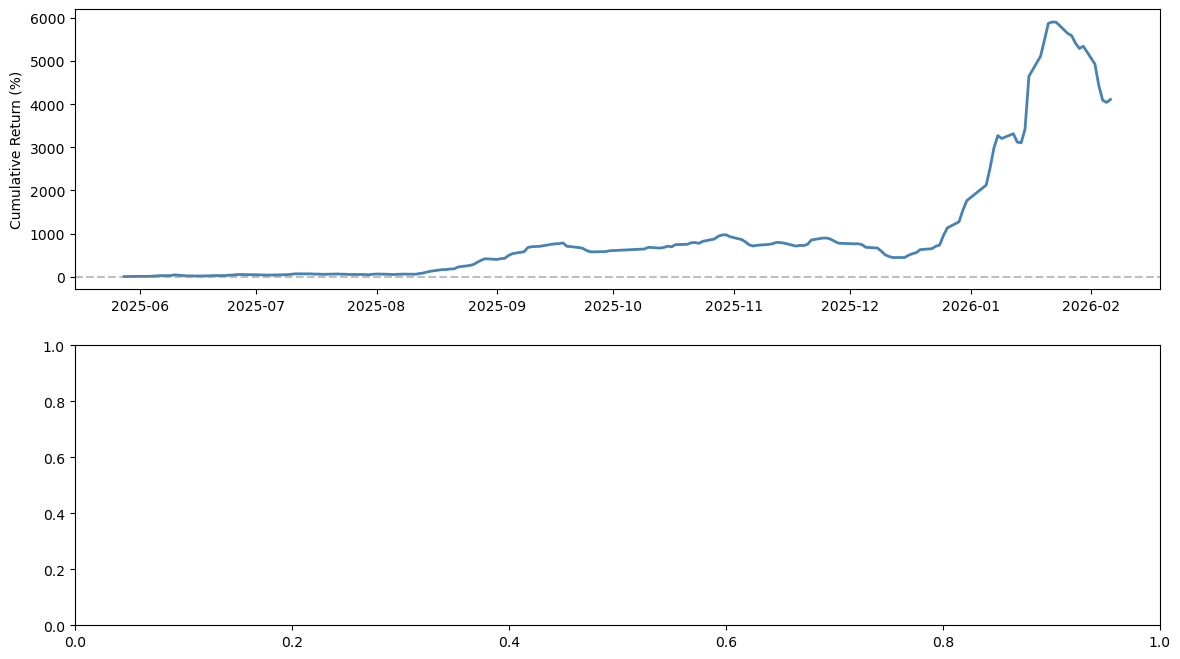

In [16]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 构建每日持仓价值变化（简化计算）
daily_returns = test_features.groupby('date').apply(
    lambda x: x.nlargest(5, 'pred_return')['target_return_5d'].mean()
).fillna(0)

# 计算累计收益
cumulative = (1 + daily_returns).cumprod() - 1

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# 累计收益
axes[0].plot(cumulative.index, cumulative * 100, linewidth=2, color='steelblue')
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_ylabel('Cumulative Return (%)')
axes[0].set_title(f"ML Strategy Backtest (Top-5) | Total Return: {backtest_result['total_return']*100:.2f}%")
axes[0].grid(True, alpha=0.3)

# 每日收益分布
colors = ['green' if r > 0 else 'red' for r in daily_returns]
axes[1].bar(daily_returns.index, daily_returns * 100, color=colors, alpha=0.6)
axes[1].axhline(0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_ylabel('Daily Return (%)')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 9.3 对比不同 Top-K 设置\n\n测试每日选不同数量的股票对收益的影响。

In [ ]:
# 对比不同 top_k 设置
top_k_values = [3, 5, 10, 15]
comparison_results = []

print('🔍 测试不同 Top-K 设置...')
print('='*60)

if 'y_pred' not in dir():
    print('⚠️ 请先运行模型预测 Cell（生成 y_pred）')
else:
    for k in top_k_values:
        result = run_backtrader_with_predictions(
            test_df=test_features,
            pred_col='pred_return',
            top_k=k,
            initial_cash=100000.0,
            commission=0.001,
            print_log=False  # 关闭日志避免刷屏
        )

        comparison_results.append({
            'top_k': k,
            'total_return': result['total_return'] * 100,
            'sharpe': result['sharpe_ratio'],
            'max_dd': result['max_drawdown'] * 100
        })

        print(f"Top-{k:2d}: 收益 {result['total_return']*100:6.2f}% | "
              f"夏普 {result['sharpe_ratio']:.3f} | "
              f"回撤 {result['max_drawdown']*100:5.2f}%")

    # 可视化对比
    import pandas as pd
    comparison_df = pd.DataFrame(comparison_results)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    metrics = ['total_return', 'sharpe', 'max_dd']
    titles = ['Total Return (%)', 'Sharpe Ratio', 'Max Drawdown (%)']
    colors = ['steelblue', 'orange', 'coral']

    for ax, metric, title, color in zip(axes, metrics, titles, colors):
        ax.bar(comparison_df['top_k'].astype(str), comparison_df[metric], color=color, alpha=0.7)
        ax.set_xlabel('Top-K')
        ax.set_ylabel(title)
        ax.set_title(title)
        ax.grid(True, alpha=0.3, axis='y')

        # 标注数值
        for i, v in enumerate(comparison_df[metric]):
            ax.text(i, v, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

## 10. 总结\n\n本 Notebook 展示了完整的 ML 量化流程：\n\n1. ✅ **数据加载**：使用 `StockDataLoader` 加载历史数据\n2. ✅ **特征工程**：自动计算技术指标（MA, RSI, MACD, KDJ等）\n3. ✅ **模型训练**：支持多种可插拔模型（RF/XGB/LGBM/MLP）\n4. ✅ **模型评估**：RMSE, MAE, R², 方向准确率\n5. ✅ **回测对比**：VectorBT（快速）vs Backtrader（详细）\n\n### 关键发现\n- 不同模型的预测能力有差异，建议多模型集成\n- Top-K 选股数量影响收益和波动，需要权衡\n- Backtrader 提供详细的交易记录，适合精细分析